In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.animation import FuncAnimation
from torch.utils.data import DataLoader, TensorDataset

# Adjust sys path for imports
sys.path.append(os.path.abspath("../"))
from src.lyap import NN_LyapExp
from src.networks import NeuralODEClassifier, NeuralODE_Truncated, init_weights, NeuralODE_Full
from src.utils import lyapunov_autograd, train, lyapunov_autograd_full

# Colormap
tf_playground = LinearSegmentedColormap.from_list(
    "tf_playground", ["#f4a261", "#ffffff", "#2a9df4"]
)

# Load Data
data_train = np.load("circle_anode_train.npz")
X_train, y_train = data_train["X"], data_train["y"]

data_val = np.load("circle_anode_val.npz")
X_val, y_val = data_val["X"], data_val["y"]

# Standardize
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_std = torch.tensor((X_train - mean) / std, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_std = torch.tensor((X_val - mean) / std, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

train_dataloader = DataLoader(TensorDataset(X_train_std, y_train_t), batch_size=64, shuffle=True)
val_dataloader = DataLoader(TensorDataset(X_val_std, y_val_t), batch_size=64)

# Grid parameters for FTLE and Prediction Space
x_vals = np.linspace(-2, 2, 50)
y_vals = np.linspace(-2, 2, 50)    

In [2]:
import math
import torch
import torch.nn as nn


def initialize_with_interpolated_scale(
    module,
    alpha=0.0,
    target_std=0.9
):
    """
    alpha = 0.0:
        approximately PyTorch default scale

    alpha = 1.0:
        Gaussian(0, target_std)

    logarithmic interpolation in variance scale
    """

    if isinstance(module, nn.Linear):

        fan_in = module.weight.size(1)

        # Std equivalent of PyTorch default Uniform init
        #
        # U(-a, a),  a = 1/sqrt(fan_in)
        # std = a / sqrt(3)
        default_std = 1.0 / math.sqrt(3.0 * fan_in)

        # Logarithmic interpolation
        sigma = default_std * (
            target_std / default_std
        ) ** alpha

        nn.init.normal_(
            module.weight,
            mean=0.0,
            std=sigma
        )

        if module.bias is not None:
            nn.init.zeros_(module.bias)

In [3]:
def get_interpolated_model(alpha, seed=45):

    torch.manual_seed(seed)

    model = NeuralODEClassifier(
        input_dim=2,
        hidden_dim=3
    )

    model.apply(
        lambda m: initialize_with_interpolated_scale(
            m,
            alpha=alpha,
            target_std=0.9
        )
    )

    return model

In [4]:
seeds = range(10)
stats = {
    "alpha": [],

    "largest_mean": [],
    "largest_std": [],
    "largest_median": [],
    "largest_positive_fraction": [],

    "smallest_mean": [],
    "smallest_std": [],
    "smallest_median": [],
    "smallest_positive_fraction": [],
}

In [5]:
# # ============================================================
# # INITIALIZATION INTERPOLATION ANALYSIS
# # FULL 3D AUGMENTED-SPACE FTLE SPECTRUM
# # ============================================================

# alphas = [0.0, 0.1, 0.2, 0.3, 0.4,
#           0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# loss_fn = nn.SmoothL1Loss()

# # ============================================================
# # GLOBAL STATISTICS CONTAINER
# # ============================================================

# stats = {
#     "alpha": [],

#     # Shape after run:
#     #
#     # stats["means"][alpha_idx][seed_idx][ftle_idx]
#     #
#     # ftle_idx:
#     # 0 -> largest
#     # 1 -> middle
#     # 2 -> smallest

#     "means": [],
#     "medians": [],
#     "positive_fractions": [],
# }

# # ============================================================
# # MAIN ANALYSIS LOOP
# # ============================================================

# for alpha in alphas:

#     print(f"\n{'='*60}")
#     print(f"Running Analysis for Alpha = {alpha}")
#     print(f"{'='*60}")

#     # --------------------------------------------------------
#     # Per-alpha accumulators
#     # --------------------------------------------------------

#     alpha_means = []
#     alpha_medians = []
#     alpha_positive_fractions = []

#     # ========================================================
#     # LOOP OVER SEEDS
#     # ========================================================

#     for seed in seeds:

#         print(f"\nSeed {seed}")

#         # ----------------------------------------------------
#         # Setup directories
#         # ----------------------------------------------------

#         save_dir = Path(
#             f"../pics/circle_node/init_analysis_simple_3exp/alpha_{alpha}/seed_{seed}"
#         )

#         save_dir.mkdir(parents=True, exist_ok=True)

#         # ----------------------------------------------------
#         # Initialize + Train model
#         # ----------------------------------------------------

#         model = get_interpolated_model(alpha, seed=seed)

#         train(
#             model,
#             train_dataloader,
#             val_dataloader,
#             loss_fn,
#             acc_target=0.95,
#             seed=seed,
#             epochs=1000
#         )

#         # ----------------------------------------------------
#         # Compute FULL 3D FTLE spectrum
#         # ----------------------------------------------------

#         print("Computing FTLE Spectrum...")

#         model_full = NeuralODE_Full(
#             neural_ode_model=model
#         )

#         ftle1_grid, ftle2_grid, ftle3_grid = (
#             lyapunov_autograd_full(
#                 x_vals,
#                 y_vals,
#                 model_full,
#                 mean,
#                 std,
#                 t0=0.0,
#                 t1=1.0
#             )
#         )

#         ftle_grids = [
#             ftle1_grid,
#             ftle2_grid,
#             ftle3_grid
#         ]

#         # ----------------------------------------------------
#         # Statistics for current seed
#         # ----------------------------------------------------

#         current_means = []
#         current_medians = []
#         current_positive_fractions = []

#         for grid in ftle_grids:

#             vals = grid[np.isfinite(grid)]

#             current_means.append(
#                 np.mean(vals)
#             )

#             current_medians.append(
#                 np.median(vals)
#             )

#             current_positive_fractions.append(
#                 np.mean(vals > 0)
#             )

#         # ----------------------------------------------------
#         # Save current seed statistics
#         # ----------------------------------------------------

#         alpha_means.append(current_means)
#         alpha_medians.append(current_medians)
#         alpha_positive_fractions.append(
#             current_positive_fractions
#         )

#         print("FTLE statistics:")
#         print("Means:", current_means)
#         print("Medians:", current_medians)
#         print("Positive fractions:",
#               current_positive_fractions)

#         # ====================================================
#         # SAVE FTLE HEATMAPS
#         # ====================================================

#         ftle_titles = [
#             "Largest FTLE",
#             "Middle FTLE",
#             "Smallest FTLE"
#         ]

#         for idx, grid in enumerate(ftle_grids):

#             fig, ax = plt.subplots(figsize=(6,6))

#             vmax = np.max(np.abs(grid))

#             im = ax.imshow(
#                 grid,
#                 extent=[
#                     x_vals.min(),
#                     x_vals.max(),
#                     y_vals.min(),
#                     y_vals.max()
#                 ],
#                 origin='lower',
#                 cmap='coolwarm',
#                 vmin=-vmax,
#                 vmax=vmax
#             )

#             fig.colorbar(
#                 im,
#                 ax=ax,
#                 label=ftle_titles[idx]
#             )

#             ax.set_title(
#                 f"{ftle_titles[idx]} (Alpha={alpha})"
#             )

#             fig.savefig(
#                 save_dir / f"ftle_{idx+1}.png",
#                 dpi=300,
#                 bbox_inches='tight'
#             )

#             plt.close(fig)

#         # ====================================================
#         # PREDICTION FIELD
#         # ====================================================

#         X, Y = np.meshgrid(x_vals, y_vals)

#         points = np.stack(
#             [X.ravel(), Y.ravel()],
#             axis=1
#         )

#         points_t = torch.tensor(
#             points,
#             dtype=torch.float32
#         )

#         points_t = (
#             (points_t - mean) / std
#         ).float()

#         model.eval()

#         with torch.no_grad():

#             preds = model(points_t).cpu().numpy()

#         Z = preds.reshape(
#             len(y_vals),
#             len(x_vals)
#         )

#         fig, ax = plt.subplots(figsize=(6,6))

#         im = ax.imshow(
#             Z,
#             extent=[
#                 x_vals.min(),
#                 x_vals.max(),
#                 y_vals.min(),
#                 y_vals.max()
#             ],
#             origin='lower',
#             cmap=tf_playground
#         )

#         fig.colorbar(
#             im,
#             ax=ax,
#             label="Prediction value"
#         )

#         ax.set_title(
#             f"Prediction Field (Alpha={alpha})"
#         )

#         fig.savefig(
#             save_dir / "prediction_field.png",
#             dpi=300
#         )

#         plt.close(fig)

#         # ====================================================
#         # TRAJECTORY VISUALIZATION
#         # ====================================================

#         print("Generating trajectories...")

#         t_eval = torch.linspace(0, 1, 100)

#         with torch.no_grad():

#             traj = model.get_hidden_trajectory(
#                 points_t,
#                 t_eval
#             )

#         traj_np = traj.cpu().numpy()

#         # ----------------------------------------------------
#         # True colors
#         # ----------------------------------------------------

#         x_colors = points_t[:, 0]
#         y_colors = points_t[:, 1]

#         labels = torch.where(
#             (x_colors**2 + y_colors**2) <= 1,
#             -1,
#             1
#         )

#         colors_true = torch.zeros(
#             (points_t.shape[0], 3)
#         )

#         colors_true[labels == -1] = torch.tensor(
#             [1.0, 0.0, 0.0]
#         )

#         colors_true[labels == 1] = torch.tensor(
#             [0.0, 0.0, 1.0]
#         )

#         colors_np = colors_true.numpy()

#         # ----------------------------------------------------
#         # GIF animation
#         # ----------------------------------------------------

#         T_frames, _, _ = traj_np.shape

#         fig = plt.figure(figsize=(6,6))

#         ax = fig.add_subplot(
#             111,
#             projection='3d'
#         )

#         scatter = ax.scatter(
#             traj_np[0,:,0],
#             traj_np[0,:,1],
#             traj_np[0,:,2],
#             c=colors_np,
#             s=5
#         )

#         ax.set_xlim(
#             traj_np[:,:,0].min(),
#             traj_np[:,:,0].max()
#         )

#         ax.set_ylim(
#             traj_np[:,:,1].min(),
#             traj_np[:,:,1].max()
#         )

#         ax.set_zlim(
#             traj_np[:,:,2].min(),
#             traj_np[:,:,2].max()
#         )

#         def update(frame):

#             scatter._offsets3d = (
#                 traj_np[frame,:,0],
#                 traj_np[frame,:,1],
#                 traj_np[frame,:,2]
#             )

#             ax.set_title(
#                 f"Alpha={alpha} | "
#                 f"t={frame/(T_frames-1):.2f}"
#             )

#             return scatter,

#         anim = FuncAnimation(
#             fig,
#             update,
#             frames=T_frames,
#             interval=80
#         )

#         anim.save(
#             save_dir / "hidden_flow.gif",
#             writer="pillow",
#             fps=15
#         )

#         plt.close(fig)

#     # ========================================================
#     # SAVE ALPHA-LEVEL STATISTICS
#     # ========================================================

#     stats["alpha"].append(alpha)

#     stats["means"].append(
#         alpha_means
#     )

#     stats["medians"].append(
#         alpha_medians
#     )

#     stats["positive_fractions"].append(
#         alpha_positive_fractions
#     )

#     print(f"\nFinished Alpha = {alpha}")

In [6]:
# Use logarithmically spaced alphas to analyze the transition
alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

loss_fn = nn.SmoothL1Loss()

for alpha in alphas:

    print(f"\n{'='*50}")
    print(f"Running Analysis for Alpha = {alpha}")
    print(f"{'='*50}")

    # Per-alpha accumulators
    largest_means = []
    largest_medians = []
    largest_positive_fractions = []

    smallest_means = []
    smallest_medians = []
    smallest_positive_fractions = []
    
    for seed in seeds:
        # Setup directories
        save_dir = Path(f"../pics/circle_node/init_analysis_simple/alpha_{alpha}/seed_{seed}")
        save_dir.mkdir(parents=True, exist_ok=True)
        print(f"Seed {seed}")

        # --------------------------------
        # Initialize + train
        # --------------------------------
        model = get_interpolated_model(alpha, seed=seed)

        train(
            model,
            train_dataloader,
            val_dataloader,
            loss_fn,
            acc_target=0.95,
            seed=seed,
            epochs=1000
        )
    
        # 2. Compute Lyapunov Exponents
        print("Computing Lyapunov Grids...")
        model_trunc = NeuralODE_Truncated(neural_ode_model=model)
        # Using your util that inherently processes the grid!
        lyap_grid, lyap_grid_min = lyapunov_autograd(x_vals, y_vals, model_trunc, mean, std, t0=0.0, t1=1.0)

        # ============================================
        # Remove NaNs/Infs
        # ============================================

        largest_vals = lyap_grid[np.isfinite(lyap_grid)]
        smallest_vals = lyap_grid_min[np.isfinite(lyap_grid_min)]

        # ============================================
        # Largest FTLE statistics
        # ============================================

        largest_means.append(np.mean(largest_vals))
        largest_medians.append(np.median(largest_vals))

        largest_positive_fractions.append(
            np.mean(largest_vals > 0)
        )

        # ============================================
        # Smallest FTLE statistics
        # ============================================

        smallest_means.append(np.mean(smallest_vals))
        smallest_medians.append(np.median(smallest_vals))

        smallest_positive_fractions.append(
            np.mean(smallest_vals > 0)
        )
    
        # Plot & Save Largest FTLE
        fig, ax = plt.subplots(figsize=(6,6))
        v = np.max(np.abs(lyap_grid))
        im = ax.imshow(lyap_grid, extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
                    origin='lower', cmap='coolwarm', vmin=-v, vmax=v)
        fig.colorbar(im, ax=ax, label="Largest (FT) Lyapunov Exponent")
        ax.set_title(f"Largest FTLE (Alpha={alpha})")
        fig.savefig(save_dir / "ftle_largest.png", dpi=300, bbox_inches='tight')
        plt.close(fig)
        
        # Plot & Save Smallest FTLE
        fig, ax = plt.subplots(figsize=(6,6))
        v = np.max(np.abs(lyap_grid_min))
        im = ax.imshow(lyap_grid_min, extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
                    origin='lower', cmap='coolwarm', vmin=-v, vmax=v)
        fig.colorbar(im, ax=ax, label="Smallest (FT) Lyapunov Exponent")
        ax.set_title(f"Smallest FTLE (Alpha={alpha})")
        fig.savefig(save_dir / "ftle_smallest.png", dpi=300, bbox_inches='tight')
        plt.close(fig)
        
        # 3. Compute Prediction Field
        X, Y = np.meshgrid(x_vals, y_vals)
        points = np.stack([X.ravel(), Y.ravel()], axis=1)
        points_t = torch.tensor(points, dtype=torch.float32)
        points_t = ((points_t - mean) / std).float()
        
        model.eval()
        with torch.no_grad():
            preds = model(points_t).cpu().numpy()
            
        Z = preds.reshape(len(y_vals), len(x_vals))
        
        # Plot & Save Prediction Field
        fig, ax = plt.subplots(figsize=(6,6))
        im = ax.imshow(Z, extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
                    origin='lower', cmap=tf_playground)
        fig.colorbar(im, ax=ax, label="Prediction value")
        ax.set_title(f"Neural ODE Prediction Field (Alpha={alpha})")
        fig.savefig(save_dir / "prediction_field.png", dpi=300)
        plt.close(fig)
        
        # 4. Trajectory and GIF generation
        print("Generating Hidden Flow Trajectories...")
        t_eval = torch.linspace(0, 1, 100)
        with torch.no_grad():
            traj = model.get_hidden_trajectory(points_t, t_eval)
            
        T_frames, N_points, _ = traj.shape
        traj_np = traj.cpu().numpy()
        
        # Setup Colors True Labels
        x_colors, y_colors = points_t[:, 0], points_t[:, 1]
        labels = torch.where((x_colors**2 + y_colors**2) <= 1, -1, 1)
        colors_true = torch.zeros((points_t.shape[0], 3))
        colors_true[labels == -1] = torch.tensor([1.0, 0.0, 0.0]) # Red inside
        colors_true[labels == 1]  = torch.tensor([0.0, 0.0, 1.0]) # Blue outside
        colors_np = colors_true.numpy()
        
        # GIF Animation
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(traj_np[0,:,0], traj_np[0,:,1], traj_np[0,:,2], c=colors_np, s=5)
        
        ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
        ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
        ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())
        
        def update(frame):
            scatter._offsets3d = (traj_np[frame,:,0], traj_np[frame,:,1], traj_np[frame,:,2])
            ax.set_title(f"Alpha={alpha} | t={1*frame/(T_frames-1):.2f}")
            return scatter,
            
        anim = FuncAnimation(fig, update, frames=T_frames, interval=80)
        anim.save(save_dir / "hidden_flow.gif", writer="pillow", fps=15)
        plt.close(fig)
        
        # 5. Final Frame True vs Pred Plot
        W = model.final_layer.weight.data.cpu().numpy()
        b = model.final_layer.bias.data.cpu().numpy()
        xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                            np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
        zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]
        
        # Save Final Frame (True Colors)
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2], c=colors_np, s=5)
        ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)
        ax.set_title(f"Final Hidden States (True Classes, Alpha={alpha})")
        fig.savefig(save_dir / "final_frame_true.png", dpi=300)
        plt.close(fig)
        
        # Save Final Frame (Prediction Colors)
        Z_norm = (Z.ravel() + 1) / 2
        colors_pred = tf_playground(Z_norm)
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2], c=colors_pred, s=5)
        ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)
        ax.set_title(f"Final Hidden States (Predicted Classes, Alpha={alpha})")
        fig.savefig(save_dir / "final_frame_pred.png", dpi=300)
        plt.close(fig)

    # ============================================
    # Aggregate statistics across seeds
    # ============================================

    stats["alpha"].append(alpha)

    stats["largest_mean"].append(largest_means)
    stats["largest_std"].append(largest_means)
    stats["largest_median"].append(largest_medians)
    stats["largest_positive_fraction"].append(largest_positive_fractions)

    stats["smallest_mean"].append(smallest_means)
    stats["smallest_std"].append(smallest_means)
    stats["smallest_median"].append(smallest_medians)
    stats["smallest_positive_fraction"].append(smallest_positive_fractions)
        
    print(f"Finished Alpha = {alpha}. Outputs saved to: {save_dir}\n")


Running Analysis for Alpha = 0.0
Seed 0
Epoch 0 | Train Loss 0.719554 | Validation Accuracy 0.520000
Epoch 20 | Train Loss 0.422448 | Validation Accuracy 0.680000
Epoch 40 | Train Loss 0.403078 | Validation Accuracy 0.680000
Epoch 60 | Train Loss 0.243176 | Validation Accuracy 0.938333
Epoch 80 | Train Loss 0.115432 | Validation Accuracy 0.940000
Epoch 100 | Train Loss 0.106893 | Validation Accuracy 0.951667
Epoch 120 | Train Loss 0.102073 | Validation Accuracy 0.955000
Epoch 140 | Train Loss 0.090776 | Validation Accuracy 0.963333
Early stopping: reached 95.0% validation accuracy
Computing Lyapunov Grids...
Generating Hidden Flow Trajectories...
Seed 1
Epoch 0 | Train Loss 0.503788 | Validation Accuracy 0.440000
Epoch 20 | Train Loss 0.419395 | Validation Accuracy 0.680000
Epoch 40 | Train Loss 0.418785 | Validation Accuracy 0.680000
Epoch 60 | Train Loss 0.401647 | Validation Accuracy 0.680000
Epoch 80 | Train Loss 0.352493 | Validation Accuracy 0.633333
Epoch 100 | Train Loss 0.316

In [7]:
save_dir = Path(
            f"../pics/circle_node/init_analysis_simple/alpha_{alpha}/stats"
        )

save_dir.mkdir(parents=True, exist_ok=True)

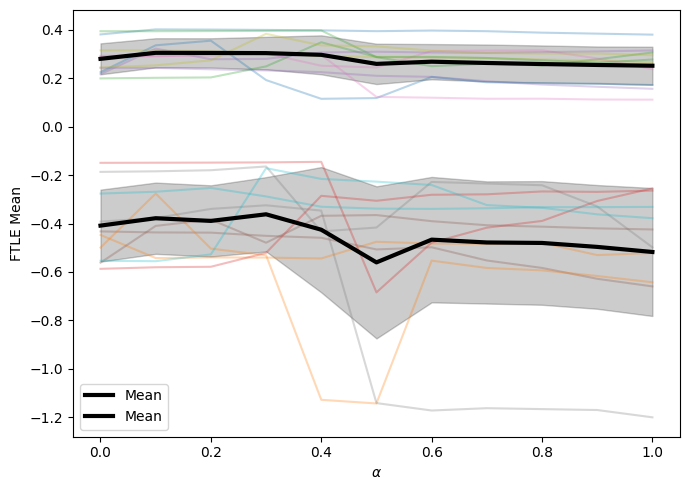

In [8]:
fig, ax = plt.subplots(figsize=(7,5))

largest_array = np.array(stats["largest_mean"])
smallest_array = np.array(stats["smallest_mean"])

# Plot one line per seed
for seed_idx in range(len(seeds)):

    ax.plot(
        alphas,
        largest_array[:, seed_idx],   # exponent 0 = largest
        alpha=0.3
    )

    ax.plot(
        alphas,
        smallest_array[:, seed_idx],   # exponent 0 = largest
        alpha=0.3
    )

# Mean across seeds
largest_mean_curve = largest_array.mean(axis=1)
smallest_mean_curve = smallest_array.mean(axis=1)

# Std across seeds
std_curve = largest_array.std(axis=1)
smallest_std = smallest_array.std(axis=1)

ax.plot(
    alphas,
    largest_mean_curve,
    color='black',
    linewidth=3,
    label='Mean'
)

ax.plot(
    alphas,
    smallest_mean_curve,
    color='black',
    linewidth=3,
    label='Mean' 
)

ax.fill_between(
    alphas,
    largest_mean_curve - std_curve,
    largest_mean_curve + std_curve,
    color='black',
    alpha=0.2
)

ax.fill_between(
    alphas,
    smallest_mean_curve - smallest_std,
    smallest_mean_curve + smallest_std,
    color='black',
    alpha=0.2
)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("FTLE Mean")

ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(save_dir / "x   x   mean.png", dpi=300)

In [9]:
# fig, ax = plt.subplots(figsize=(7,5))

# largest_array = np.array(stats["means"])

# # Plot one line per seed
# for seed_idx in range(len(seeds)):

#     ax.plot(
#         alphas,
#         largest_array[:, seed_idx, 1],   # exponent 0 = largest
#         alpha=0.3
#     )

# # Mean across seeds
# mean_curve = largest_array[:, :, 1].mean(axis=1)

# # Std across seeds
# std_curve = largest_array[:, :, 1].std(axis=1)

# ax.plot(
#     alphas,
#     mean_curve,
#     color='black',
#     linewidth=3,
#     label='Mean'
# )

# ax.fill_between(
#     alphas,
#     mean_curve - std_curve,
#     mean_curve + std_curve,
#     color='black',
#     alpha=0.2
# )

# ax.set_xlabel(r"$\alpha$")
# ax.set_ylabel("Second FTLE Mean")

# ax.legend()

# plt.tight_layout()
# plt.show()

# fig.savefig(save_dir / "second_mean.png", dpi=300)

In [10]:
# fig, ax = plt.subplots(figsize=(7,5))

# largest_array = np.array(stats["means"])

# # Plot one line per seed
# for seed_idx in range(len(seeds)):

#     ax.plot(
#         alphas,
#         largest_array[:, seed_idx, 2],   # exponent 0 = largest
#         alpha=0.3
#     )

# # Mean across seeds
# mean_curve = largest_array[:, :, 2].mean(axis=1)

# # Std across seeds
# std_curve = largest_array[:, :, 2].std(axis=1)

# ax.plot(
#     alphas,
#     mean_curve,
#     color='black',
#     linewidth=3,
#     label='Mean'
# )

# ax.fill_between(
#     alphas,
#     mean_curve - std_curve,
#     mean_curve + std_curve,
#     color='black',
#     alpha=0.2
# )

# ax.set_xlabel(r"$\alpha$")
# ax.set_ylabel("Smallest FTLE Mean")

# ax.legend()

# plt.tight_layout()
# plt.show()

# fig.savefig(save_dir / "smallest_mean.png", dpi=300)

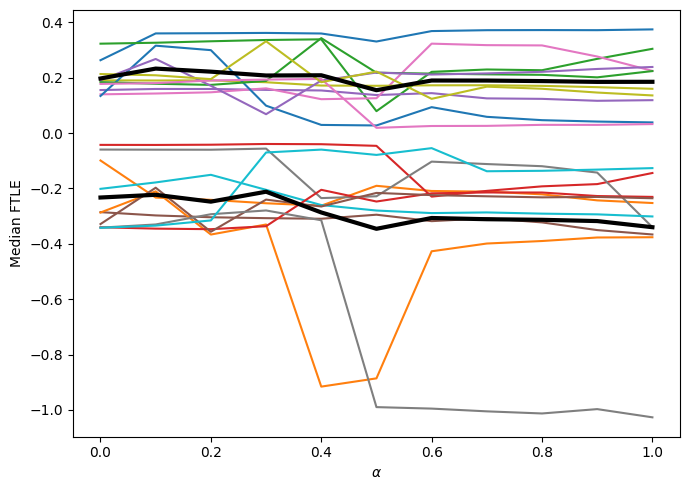

In [11]:
fig, ax = plt.subplots(figsize=(7,5))

largest_medians_array = np.array(stats["largest_median"])
smallest_medians_array = np.array(stats["smallest_median"])

for seed in range(len(seeds)):

    ax.plot(
        stats["alpha"],
        largest_medians_array[:, seed],
        label=f"Largest Median | seed={seed}"
    )

    ax.plot(
        stats["alpha"],
        smallest_medians_array[:, seed],
        label=f"Largest Median | seed={seed}"
    )

largest_mean = largest_medians_array.mean(axis=1)
smallest_mean = smallest_medians_array.mean(axis=1)

ax.plot(
    stats["alpha"],
    largest_mean,
    linewidth=3,
    label="Largest Median Mean",
    color='black'
)
ax.plot(
    stats["alpha"],
    smallest_mean,
    linewidth=3,
    label="Largest Median Mean",
    color='black'
)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Median FTLE")

plt.tight_layout()
plt.show()

fig.savefig(save_dir / "median.png", dpi=300)

In [12]:
# fig, ax = plt.subplots(figsize=(7,5))

# for seed in range(len(seeds)):

#     ax.plot(
#         stats["alpha"],
#         largest_medians_array[:, seed, 1],
#         label=f"Second Median | seed={seed}"
#     )

# largest_mean = largest_medians_array[:, :, 1].mean(axis=1)


# ax.plot(
#     stats["alpha"],
#     largest_mean,
#     linewidth=3,
#     label="Second Median Mean",
#     color='black'
# )

# ax.set_xlabel(r"$\alpha$")
# ax.set_ylabel("Median Second FTLE")

# plt.tight_layout()
# plt.show()

# fig.savefig(save_dir / "second_median.png", dpi=300)

In [13]:
# fig, ax = plt.subplots(figsize=(7,5))

# for seed in range(len(seeds)):

#     ax.plot(
#         stats["alpha"],
#         largest_medians_array[:, seed, 2],
#         label=f"Smallest Median | seed={seed}"
#     )

# largest_mean = largest_medians_array[:, :, 2].mean(axis=1)

# ax.plot(
#     stats["alpha"],
#     largest_mean,
#     linewidth=3,
#     label="Smallest Median Mean",
#     color='black'
# )

# ax.set_xlabel(r"$\alpha$")
# ax.set_ylabel("Median Smallest FTLE")

# plt.tight_layout()
# plt.show()

# fig.savefig(save_dir / "smallest_median.png", dpi=300)

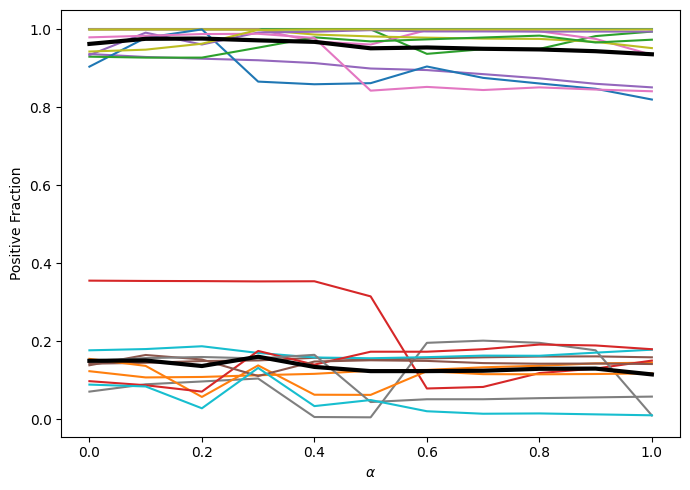

In [15]:
fig, ax = plt.subplots(figsize=(7,5))

positive_fractions_array = np.array(stats['largest_positive_fraction'])
spositive_fractions_array = np.array(stats["smallest_positive_fraction"])

for seed in range(len(seeds)):
    ax.plot(
        stats["alpha"],
        positive_fractions_array[:, seed],
        label=f"Largest > 0 | seed={seed}"
    )

    ax.plot(
        stats["alpha"],
        spositive_fractions_array[:, seed],
        label=f"Largest > 0 | seed={seed}"
    )

largest_mean = positive_fractions_array.mean(axis=1)
smallest_mean = spositive_fractions_array.mean(axis=1)

ax.plot(
    stats["alpha"],
    largest_mean,
    linewidth=3,
    label="Largest > 0 Mean",
    color='black'
)

ax.plot(
    stats["alpha"],
    smallest_mean,
    linewidth=3,
    label="Smallest > 0 Mean",
    color='black'
)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Positive Fraction")

plt.tight_layout()
plt.show()

fig.savefig(save_dir / "pf.png", dpi=300)

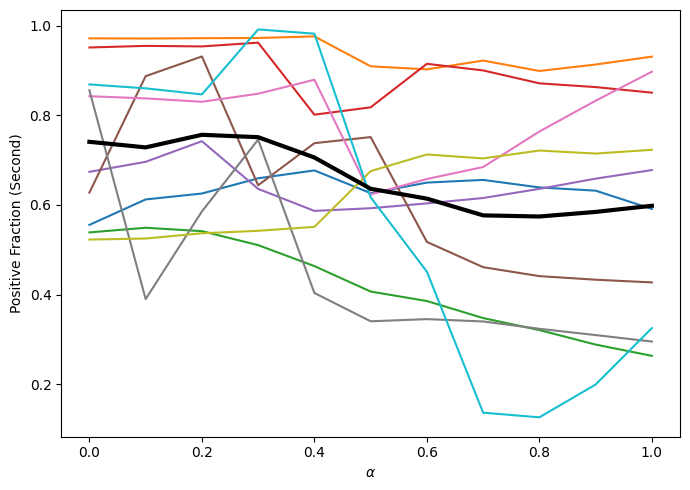

In [ ]:
# fig, ax = plt.subplots(figsize=(7,5))

# positive_fractions_array = np.array(stats['positive_fractions'])


# for seed in range(len(seeds)):
#     ax.plot(
#         stats["alpha"],
#         positive_fractions_array[:, seed, 1],
#         label=f"Largest > 0 | seed={seed}"
#     )

# largest_mean = positive_fractions_array[:, :, 1].mean(axis=1)

# ax.plot(
#     stats["alpha"],
#     largest_mean,
#     linewidth=3,
#     label="Largest > 0 Mean",
#     color='black'
# )

# ax.set_xlabel(r"$\alpha$")
# ax.set_ylabel("Positive Fraction (Second)")

# plt.tight_layout()
# plt.show()

# fig.savefig(save_dir / "second_pf.png", dpi=300)

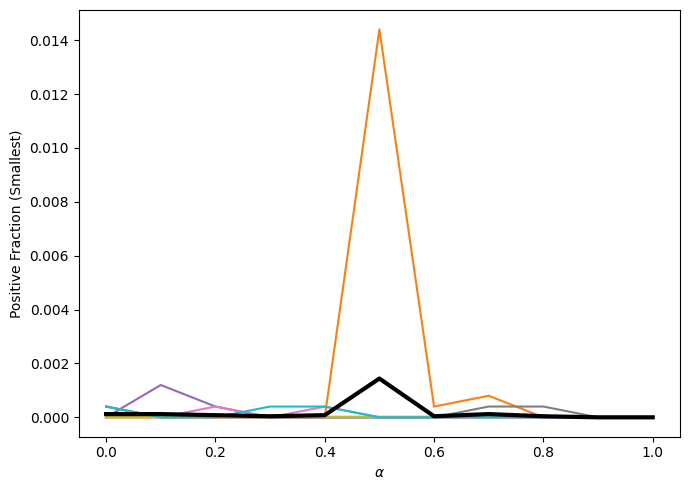

In [ ]:
# fig, ax = plt.subplots(figsize=(7,5))

# positive_fractions_array = np.array(stats['positive_fractions'])


# for seed in range(len(seeds)):
#     ax.plot(
#         stats["alpha"],
#         positive_fractions_array[:, seed, 2],
#         label=f"Largest > 0 | seed={seed}"
#     )

# largest_mean = positive_fractions_array[:, :, 2].mean(axis=1)

# ax.plot(
#     stats["alpha"],
#     largest_mean,
#     linewidth=3,
#     label="Largest > 0 Mean",
#     color='black'
# )

# ax.set_xlabel(r"$\alpha$")
# ax.set_ylabel("Positive Fraction (Smallest)")

# plt.tight_layout()
# plt.show()

# fig.savefig(save_dir / "smallest_pf.png", dpi=300)

In [16]:
import pickle

with open("ftle_statistics_simple.pkl", "wb") as f:
    pickle.dump(stats, f)

In [ ]:
print(stats["means"][0])

[[0.6573888607218862, 0.09178349555132459, -0.7555371798619628], [1.4379681582272053, 0.2625175366508494, -0.3262548999455292], [0.6153130699742585, -0.027340568954777156, -0.6176371159492526], [0.7545728819012641, 0.10366017861922446, -0.4280277239531279], [0.6490448424272472, 0.04013213686616749, -0.4514110454509209], [0.6605581470027566, -0.01210575153724941, -0.7138074724698439], [0.8340807189263404, 0.08914733869066202, -0.8219646745521575], [0.8376125957638025, 0.11371578880421007, -0.7960682723904959], [0.6220794964387547, 0.0005279628960457103, -0.5733699972274481], [0.7483237502887845, 0.11794265922462259, -0.7667866652465658]]
